<a href="https://colab.research.google.com/github/iamKrishu1916/KAN-Kolmogorov-Arnold-Networks-for-learnable-activation-function./blob/main/notebooks/multiplication_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pykan matplotlib numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.3 MB/s eta 0:00:00


checkpoint directory created: ./model
saving model version 0.0
Training on grid size 3...


| train_loss: 1.02e-03 | test_loss: 1.07e-03 | reg: 1.58e+01 | : 100%|█| 200/200 [00:52<00:00,  3.80


saving model version 0.1
Training on grid size 5...
saving model version 0.2


| train_loss: 5.64e-04 | test_loss: 6.94e-04 | reg: 1.57e+01 | : 100%|█| 200/200 [00:51<00:00,  3.87


saving model version 0.3
Training on grid size 10...
saving model version 0.4


...

saving model version 0.11
Training on grid size 200...
saving model version 0.12


| train_loss: 2.67e-07 | test_loss: 6.89e-03 | reg: 1.58e+01 | : 100%|█| 200/200 [07:04<00:00,  2.12


saving model version 0.13
Training on grid size 500...
saving model version 0.14


| train_loss: 3.77e-03 | test_loss: 3.17e-01 | reg: 7.29e+00 | : 100%|█| 200/200 [18:04<00:00,  5.42


saving model version 0.15


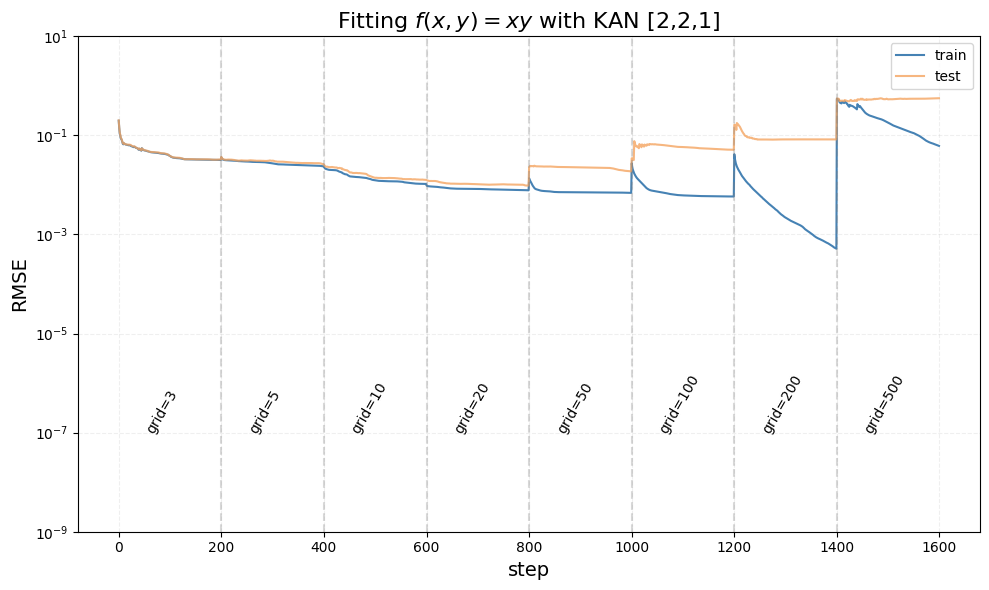

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN, create_dataset

# Force CPU and float64 for mathematical stability during spline interpolation
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

# 1. Define the synthetic dataset: f(x,y) = x * y
f = lambda x: x[:, [0]] * x[:, [1]]
dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000, device=device)

# 2. Experiment Configuration
grids = [3, 5, 10, 20, 50, 100, 200, 500]
steps_per_grid = 200

# 3. Initialize Model and Storage
# Using seed=0 is crucial for the [2,2,1] architecture to avoid flatline initializations
model = KAN(width=[2, 2, 1], grid=grids[0], k=3, seed=0, device=device)

train_rmse = []
test_rmse = []

# 4. Training Loop with Grid Extension
for g in grids:
    print(f"Training on grid size {g}...")
    if g != grids[0]:
        # Fine-grain the spline grids
        model = model.refine(g)

    # lamb=0.0 disables sparsity regularization so LBFGS focuses purely on MSE
    res = model.fit(dataset, opt="LBFGS", steps=steps_per_grid, lamb=0.0)

    # PyKAN natively returns MSE; we take sqrt for RMSE
    train_rmse.extend(np.sqrt(res['train_loss']))
    test_rmse.extend(np.sqrt(res['test_loss']))

# 5. Plotting the Training Dynamics
plt.figure(figsize=(10, 6))
steps_total = np.arange(len(grids) * steps_per_grid)

plt.semilogy(steps_total, train_rmse, label='train', color='steelblue', linewidth=1.5)
plt.semilogy(steps_total, test_rmse, label='test', color='sandybrown', linewidth=1.5, alpha=0.8)

# Add grid text annotations and vertical dividing lines
for i, g in enumerate(grids):
    plt.text(i * steps_per_grid + 50, 1e-7, f'grid={g}', rotation=60, fontsize=10)
    if i > 0:
        plt.axvline(x=i * steps_per_grid, color='gray', linestyle='--', alpha=0.3)

plt.title(r'Fitting $f(x, y) = xy$ with KAN [2,2,1]', fontsize=16)
plt.xlabel('step', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.ylim(1e-9, 1e1)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the approximate number of parameters (6 edges * G)
G = np.array(grids)
params_221 = 6 * G

# 2. Extract the final test RMSE for each grid size
# test_rmse has the loss for every single step.
# We slice it to get the value at the end of each 200-step block.
final_test_rmse = test_rmse[steps_per_grid - 1 :: steps_per_grid]

# 3. Create the plot
plt.figure(figsize=(8, 6))

# Plot Test RMSE vs Number of Parameters
plt.loglog(params_221, final_test_rmse, 'g-o', label='KAN [2,2,1]', markersize=6)

# Add a reference scaling line (e.g., P^-3) to see how steeply it learns
# Adjusting the constant multiplier (1e2) just to place it neatly on the graph
ref_line = 1e2 * params_221**(-3.0)
plt.loglog(params_221[1:6], ref_line[1:6], 'k--', alpha=0.5, label='$P^{-3}$ scaling')

# Formatting
plt.xlabel('Number of Parameters (Approximate)', fontsize=12)
plt.ylabel('Test RMSE', fontsize=12)
plt.title(r'Scaling Law: Test RMSE vs. Parameters for $f(x,y)=xy$', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'grids' is not defined

checkpoint directory created: ./model
saving model version 0.0
Training on grid size 3...


| train_loss: 1.11e-03 | test_loss: 1.17e-03 | reg: 1.61e+01 | : 100%|█| 200/200 [00:51<00:00,  3.86


saving model version 0.1
Training on grid size 5...
saving model version 0.2


| train_loss: 6.49e-04 | test_loss: 7.85e-04 | reg: 1.60e+01 | : 100%|█| 200/200 [00:52<00:00,  3.83


saving model version 0.3
Training on grid size 10...
saving model version 0.4


...

saving model version 0.5
Training on grid size 20...
saving model version 0.6


| train_loss: 7.53e-05 | test_loss: 1.23e-04 | reg: 1.61e+01 | : 100%|█| 200/200 [01:16<00:00,  2.61


saving model version 0.7
Training on grid size 50...
saving model version 0.8


| train_loss: 5.89e-05 | test_loss: 2.49e-04 | reg: 1.61e+01 | : 100%|█| 200/200 [02:09<00:00,  1.54


saving model version 0.9


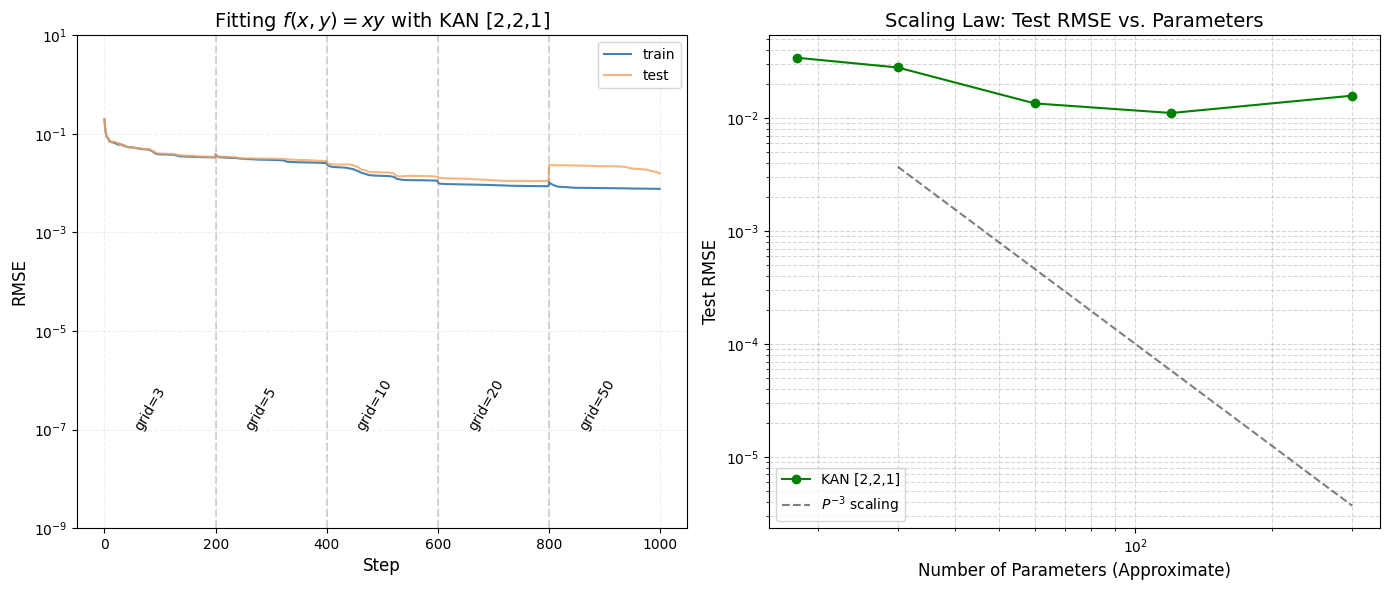

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN, create_dataset

# Force CPU and float64 for mathematical stability during spline interpolation
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

# 1. Define the synthetic dataset: f(x,y) = x * y
f = lambda x: x[:, [0]] * x[:, [1]]
dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000, device=device)

# 2. Experiment Configuration (REDUCED COMPUTE)
grids = [3, 5, 10, 20, 50]  # Stops at 50 to reduce compute time
steps_per_grid = 200        # 5 grids * 200 steps = 1000 epochs total

# 3. Initialize Model and Storage
# Using seed=0 is crucial for the [2,2,1] architecture to avoid flatline initializations
model = KAN(width=[2, 2, 1], grid=grids[0], k=3, seed=0, device=device)

train_rmse = []
test_rmse = []
final_test_rmse = []  # Added to store the final test loss of each grid block

# 4. Training Loop with Grid Extension
for g in grids:
    print(f"Training on grid size {g}...")
    if g != grids[0]:
        # Fine-grain the spline grids
        model = model.refine(g)

    # lamb=0.0 disables sparsity regularization so LBFGS focuses purely on MSE
    res = model.fit(dataset, opt="LBFGS", steps=steps_per_grid, lamb=0.0)

    # PyKAN natively returns MSE; we take sqrt for RMSE
    train_rmse.extend(np.sqrt(res['train_loss']))

    # Store test loss step-by-step for the first plot, and final loss for the second plot
    test_rmse_step = np.sqrt(res['test_loss'])
    test_rmse.extend(test_rmse_step)
    final_test_rmse.append(test_rmse_step[-1])

# 5. Plotting (UPDATED FOR TWO PLOTS)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Loss vs Steps (Training Dynamics) ---
steps_total = np.arange(len(grids) * steps_per_grid)

axs[0].semilogy(steps_total, train_rmse, label='train', color='steelblue', linewidth=1.5)
axs[0].semilogy(steps_total, test_rmse, label='test', color='sandybrown', linewidth=1.5, alpha=0.8)

# Add grid text annotations and vertical dividing lines
for i, g in enumerate(grids):
    axs[0].text(i * steps_per_grid + 50, 1e-7, f'grid={g}', rotation=60, fontsize=10)
    if i > 0:
        axs[0].axvline(x=i * steps_per_grid, color='gray', linestyle='--', alpha=0.3)

axs[0].set_title(r'Fitting $f(x, y) = xy$ with KAN [2,2,1]', fontsize=14)
axs[0].set_xlabel('Step', fontsize=12)
axs[0].set_ylabel('RMSE', fontsize=12)
axs[0].set_ylim(1e-9, 1e1)
axs[0].legend(loc='upper right')
axs[0].grid(True, which="both", ls="--", alpha=0.2)

# --- Plot 2: Loss vs Parameters (Scaling Laws) ---
G = np.array(grids)
# A [2,2,1] KAN has 4 edges in the first layer and 2 in the second = 6 edges total
params_221 = 6 * G

axs[1].loglog(params_221, final_test_rmse, 'g-o', label='KAN [2,2,1]', markersize=6)

# Add a reference scaling line to see how steeply it learns
ref_line = 1e2 * params_221**(-3.0)
axs[1].loglog(params_221[1:], ref_line[1:], 'k--', alpha=0.5, label='$P^{-3}$ scaling')

axs[1].set_title(r'Scaling Law: Test RMSE vs. Parameters', fontsize=14)
axs[1].set_xlabel('Number of Parameters (Approximate)', fontsize=12)
axs[1].set_ylabel('Test RMSE', fontsize=12)
axs[1].grid(True, which="both", ls="--", alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()